# Notebook 2: Why GPUs for Deep Learning

**Vizuara AI Pods | GPU Programming Course | Pod 1: Intro to GPUs and GPU Parallelism**

---

In the previous notebook, we explored GPU architecture and ran basic benchmarks. Now we will connect those hardware fundamentals to deep learning. Specifically, we will:

1. Understand exactly why neural networks are dominated by matrix multiplication
2. Benchmark real PyTorch neural network layers on CPU vs GPU
3. Profile a full forward and backward pass to see where time is spent
4. Calculate the memory footprint of model training and see why single GPUs run out of memory

**Prerequisites:** Notebook 1 (GPU Architecture Basics), basic PyTorch familiarity.

**Estimated time:** 45-55 minutes

**Runtime:** GPU (T4 or better) in Colab.

## Setup

In [1]:
!pip install -q torch numpy matplotlib

In [2]:
import torch
import torch.nn as nn
import numpy as np
import time
import matplotlib.pyplot as plt

assert torch.cuda.is_available(), "No GPU found! Enable GPU in Runtime > Change runtime type."
device = torch.device('cuda')
print(f"Using: {torch.cuda.get_device_name(0)}")
print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using: NVIDIA H100 80GB HBM3
GPU Memory: 85.0 GB


## Part 1: Neural Network Operations Are Matrix Multiplications

Let us verify that neural network operations really do boil down to matrix multiplication. We will manually implement a linear layer and compare it with PyTorch's built-in `nn.Linear`.

In [3]:
# A linear layer computes: y = x @ W^T + b
# Let's verify this is exactly what nn.Linear does.

batch_size = 32
d_in = 4096
d_out = 4096

# Create a linear layer
linear = nn.Linear(d_in, d_out, bias=True).to(device)

# Create input
x = torch.randn(batch_size, d_in, device=device)

# Method 1: Using nn.Linear
y_pytorch = linear(x)

# Method 2: Manual matrix multiply
y_manual = x @ linear.weight.T + linear.bias

# Verify they are the same
max_diff = (y_pytorch - y_manual).abs().max().item()


In [4]:
print(f"Max difference between nn.Linear and manual matmul: {max_diff:.2e}")
print(f"Are they (approximately) equal? {max_diff < 1e-5}")
print(f"\nMatrix multiply shape: ({batch_size}, {d_in}) @ ({d_in}, {d_out}) = ({batch_size}, {d_out})")
print(f"FLOPs for this single layer: {2 * batch_size * d_in * d_out:,}")

Max difference between nn.Linear and manual matmul: 3.04e-06
Are they (approximately) equal? True

Matrix multiply shape: (32, 4096) @ (4096, 4096) = (32, 4096)
FLOPs for this single layer: 1,073,741,824


### Counting FLOPs in a Transformer Layer

A single transformer layer contains multiple linear projections. Let's count the total FLOPs.

In [5]:
def count_transformer_flops(d_model, n_heads, d_ff, seq_len, batch_size):
    """
    Count approximate FLOPs for one transformer layer (forward pass only).

    A transformer layer contains:
    1. QKV projection: x @ W_QKV  (d_model -> 3 * d_model)
    2. Attention: Q @ K^T (seq_len x seq_len matrix per head)
    3. Attention @ V (seq_len x d_head matrix per head)
    4. Output projection: attn_out @ W_O  (d_model -> d_model)
    5. FFN layer 1: x @ W_1  (d_model -> d_ff)
    6. FFN layer 2: x @ W_2  (d_ff -> d_model)
    """
    d_head = d_model // n_heads

    # FLOPs per operation = 2 * M * N * K (for M x K @ K x N matmul)
    flops = {}

    # QKV projection: (batch, seq, d_model) @ (d_model, 3*d_model)
    flops['QKV Projection'] = 2 * batch_size * seq_len * d_model * (3 * d_model)

    # Attention scores: (batch, heads, seq, d_head) @ (batch, heads, d_head, seq)
    flops['Attention Scores (Q@K^T)'] = 2 * batch_size * n_heads * seq_len * d_head * seq_len

    # Attention output: (batch, heads, seq, seq) @ (batch, heads, seq, d_head)
    flops['Attention Output (Attn@V)'] = 2 * batch_size * n_heads * seq_len * seq_len * d_head

    # Output projection: (batch, seq, d_model) @ (d_model, d_model)
    flops['Output Projection'] = 2 * batch_size * seq_len * d_model * d_model

    # FFN layer 1: (batch, seq, d_model) @ (d_model, d_ff)
    flops['FFN Layer 1'] = 2 * batch_size * seq_len * d_model * d_ff

    # FFN layer 2: (batch, seq, d_ff) @ (d_ff, d_model)
    flops['FFN Layer 2'] = 2 * batch_size * seq_len * d_ff * d_model

    total = sum(flops.values())
    flops['TOTAL'] = total

    return flops

# LLaMA-2 7B configuration
d_model = 4096
n_heads = 32
d_ff = 11008  # LLaMA uses SwiGLU, so d_ff is larger
seq_len = 2048
batch_size = 1  # single sequence

flops = count_transformer_flops(d_model, n_heads, d_ff, seq_len, batch_size)


In [6]:
print(f"FLOPs for ONE transformer layer (LLaMA-2 7B config):")
print(f"{'Operation':<30} {'FLOPs':>20} {'% of Total':>12}")
print("=" * 65)
total = flops['TOTAL']
for name, count in flops.items():
    if name != 'TOTAL':
        print(f"{name:<30} {count:>20,} {count/total*100:>10.1f}%")
print("=" * 65)
print(f"{'TOTAL':<30} {total:>20,}")
print(f"\nThat's {total/1e9:.1f} GFLOPs for ONE layer, ONE sequence!")
print(f"LLaMA-2 7B has 32 layers, so total = {total * 32 / 1e12:.2f} TFLOPs per forward pass.")
print(f"With backward pass (~2x forward): {total * 32 * 3 / 1e12:.2f} TFLOPs per training step.")

FLOPs for ONE transformer layer (LLaMA-2 7B config):
Operation                                     FLOPs   % of Total
QKV Projection                      206,158,430,208       28.9%
Attention Scores (Q@K^T)             34,359,738,368        4.8%
Attention Output (Attn@V)            34,359,738,368        4.8%
Output Projection                    68,719,476,736        9.6%
FFN Layer 1                         184,683,593,728       25.9%
FFN Layer 2                         184,683,593,728       25.9%
TOTAL                               712,964,571,136

That's 713.0 GFLOPs for ONE layer, ONE sequence!
LLaMA-2 7B has 32 layers, so total = 22.81 TFLOPs per forward pass.
With backward pass (~2x forward): 68.44 TFLOPs per training step.


## Part 2: Benchmarking Real Neural Network Layers

Now let's benchmark actual PyTorch neural network layers -- both forward and backward passes -- on CPU vs GPU.

In [7]:
def benchmark_layer(layer_fn, input_shape, dtype=torch.float32, num_trials=5, device_name='cuda'):
    """
    Benchmark a neural network layer's forward + backward pass.
    Returns (forward_time_ms, backward_time_ms).
    """
    dev = torch.device(device_name)
    layer = layer_fn().to(dev).to(dtype)
    x = torch.randn(*input_shape, device=dev, dtype=dtype, requires_grad=True)

    # Warm up
    y = layer(x)
    loss = y.sum()
    loss.backward()
    if device_name == 'cuda':
        torch.cuda.synchronize()

    fwd_times = []
    bwd_times = []

    for _ in range(num_trials):
        x = torch.randn(*input_shape, device=dev, dtype=dtype, requires_grad=True)

        if device_name == 'cuda':
            torch.cuda.synchronize()

        # Forward
        start = time.perf_counter()
        y = layer(x)
        if device_name == 'cuda':
            torch.cuda.synchronize()
        fwd_times.append(time.perf_counter() - start)

        # Backward
        loss = y.sum()
        if device_name == 'cuda':
            torch.cuda.synchronize()
        start = time.perf_counter()
        loss.backward()
        if device_name == 'cuda':
            torch.cuda.synchronize()
        bwd_times.append(time.perf_counter() - start)

    return np.median(fwd_times) * 1000, np.median(bwd_times) * 1000


# Define layers to benchmark
batch_size = 32
seq_len = 512
d_model = 1024

layers = {
    "Linear (1024->1024)": (lambda: nn.Linear(d_model, d_model), (batch_size, seq_len, d_model)),
    "Linear (1024->4096)": (lambda: nn.Linear(d_model, 4 * d_model), (batch_size, seq_len, d_model)),
    "LayerNorm": (lambda: nn.LayerNorm(d_model), (batch_size, seq_len, d_model)),
    "GELU activation": (lambda: nn.GELU(), (batch_size, seq_len, d_model)),
    "Softmax": (lambda: nn.Softmax(dim=-1), (batch_size, seq_len, d_model)),
}


In [8]:
print(f"Benchmarking neural network layers (batch={batch_size}, seq={seq_len}, d={d_model}):")
print("=" * 100)
print(f"{'Layer':<25} {'CPU Fwd (ms)':>12} {'CPU Bwd (ms)':>12} {'GPU Fwd (ms)':>12} {'GPU Bwd (ms)':>12} {'Speedup':>10}")
print("-" * 100)

for name, (layer_fn, shape) in layers.items():
    cpu_fwd, cpu_bwd = benchmark_layer(layer_fn, shape, device_name='cpu')
    gpu_fwd, gpu_bwd = benchmark_layer(layer_fn, shape, device_name='cuda')
    speedup = (cpu_fwd + cpu_bwd) / (gpu_fwd + gpu_bwd)
    print(f"{name:<25} {cpu_fwd:>12.2f} {cpu_bwd:>12.2f} {gpu_fwd:>12.3f} {gpu_bwd:>12.3f} {speedup:>9.1f}x")

Benchmarking neural network layers (batch=32, seq=512, d=1024):
Layer                     CPU Fwd (ms) CPU Bwd (ms) GPU Fwd (ms) GPU Bwd (ms)    Speedup
----------------------------------------------------------------------------------------------------
Linear (1024->1024)              14.51       188.38        0.751        1.548      88.3x
Linear (1024->4096)             125.32       418.26        2.808        5.843      62.8x
LayerNorm                         9.85        86.20        0.082        0.314     242.4x
GELU activation                  10.84        88.98        0.061        0.119     552.9x
Softmax                          12.50        95.76        0.064        0.216     386.7x


### What Do These Results Tell Us?

Notice that:
1. **Linear layers** (matrix multiplications) get the biggest GPU speedup -- often 50-200x
2. **LayerNorm and GELU** also benefit, but less so -- they are memory-bound, not compute-bound
3. **Backward pass** is typically 1.5-2x slower than forward (it computes gradients for both weights and inputs)

The linear layers dominate total computation time, which is why GPUs are essential for deep learning.

## Part 3: Profiling a Complete Model

Let us build a small transformer-like model and profile where time is actually spent during training.

In [9]:
class SimplifiedTransformerBlock(nn.Module):
    """A simplified transformer block for profiling."""

    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.attn = nn.MultiheadAttention(d_model, n_heads, batch_first=True, dropout=dropout)
        self.norm2 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        # Self-attention with residual connection
        normed = self.norm1(x)
        attn_out, _ = self.attn(normed, normed, normed)
        x = x + attn_out

        # Feed-forward with residual connection
        normed = self.norm2(x)
        x = x + self.ffn(normed)
        return x


class SimplifiedTransformer(nn.Module):
    """A stack of transformer blocks."""

    def __init__(self, d_model=512, n_heads=8, d_ff=2048, n_layers=6, vocab_size=32000):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, d_model)
        self.blocks = nn.ModuleList([
            SimplifiedTransformerBlock(d_model, n_heads, d_ff)
            for _ in range(n_layers)
        ])
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size, bias=False)

    def forward(self, x):
        x = self.embed(x)
        for block in self.blocks:
            x = block(x)
        x = self.norm(x)
        return self.head(x)


# Create model and count parameters
model = SimplifiedTransformer(d_model=512, n_heads=8, d_ff=2048, n_layers=6).to(device)
num_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {num_params:,} ({num_params/1e6:.1f}M)")
print(f"Model memory (FP32): {num_params * 4 / 1024**2:.1f} MB")

Model parameters: 51,683,328 (51.7M)
Model memory (FP32): 197.2 MB


In [10]:
def profile_training_step(model, batch_size, seq_len, device, num_trials=3):
    """Profile a full training step: forward + loss + backward."""
    model.train()
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
    criterion = nn.CrossEntropyLoss()

    # Generate random input
    input_ids = torch.randint(0, 32000, (batch_size, seq_len), device=device)
    targets = torch.randint(0, 32000, (batch_size, seq_len), device=device)

    # Warm up
    logits = model(input_ids)
    loss = criterion(logits.view(-1, logits.size(-1)), targets.view(-1))
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    if device.type == 'cuda':
        torch.cuda.synchronize()

    # Profile
    fwd_times, bwd_times, opt_times, total_times = [], [], [], []

    for _ in range(num_trials):
        optimizer.zero_grad()

        if device.type == 'cuda':
            torch.cuda.synchronize()

        # Forward pass
        t0 = time.perf_counter()
        logits = model(input_ids)
        loss = criterion(logits.view(-1, logits.size(-1)), targets.view(-1))
        if device.type == 'cuda':
            torch.cuda.synchronize()
        t1 = time.perf_counter()

        # Backward pass
        loss.backward()
        if device.type == 'cuda':
            torch.cuda.synchronize()
        t2 = time.perf_counter()

        # Optimizer step
        optimizer.step()
        if device.type == 'cuda':
            torch.cuda.synchronize()
        t3 = time.perf_counter()

        fwd_times.append((t1 - t0) * 1000)
        bwd_times.append((t2 - t1) * 1000)
        opt_times.append((t3 - t2) * 1000)
        total_times.append((t3 - t0) * 1000)

    return {
        'forward': np.median(fwd_times),
        'backward': np.median(bwd_times),
        'optimizer': np.median(opt_times),
        'total': np.median(total_times),
    }


# Profile on GPU
gpu_times = profile_training_step(model, batch_size=16, seq_len=256, device=device)

print(f"\nGPU Training Step Profile (batch=16, seq=256):")
print("=" * 50)
for phase, t in gpu_times.items():
    bar = '#' * int(t / gpu_times['total'] * 40)
    print(f"  {phase:<12}: {t:8.2f} ms  {bar} ({t/gpu_times['total']*100:.0f}%)")

print(f"\nKey Insight: The backward pass is ~{gpu_times['backward']/gpu_times['forward']:.1f}x the forward pass.")
print(f"This is because gradients must be computed for every weight AND every activation.")


GPU Training Step Profile (batch=16, seq=256):
  forward     :     9.00 ms  ############ (32%)
  backward    :    17.10 ms  ######################## (61%)
  optimizer   :     2.14 ms  ### (8%)
  total       :    28.20 ms  ######################################## (100%)

Key Insight: The backward pass is ~1.9x the forward pass.
This is because gradients must be computed for every weight AND every activation.


## Part 4: Memory Analysis -- Why Single GPUs Run Out

Let us carefully track GPU memory during a training step to see exactly where the memory goes.

In [11]:
def analyze_training_memory(d_model, n_layers, vocab_size, batch_size, seq_len):
    """
    Calculate the theoretical memory breakdown for training a transformer model.
    """
    # Approximate parameter count
    d_ff = 4 * d_model
    params_per_layer = (
        4 * d_model * d_model +    # QKV + output projections
        2 * d_model * d_ff +       # FFN up + down
        4 * d_model                 # LayerNorm params (2 norms, each with weight + bias)
    )
    total_params = (
        vocab_size * d_model +      # Embedding
        n_layers * params_per_layer + # Transformer layers
        d_model +                   # Final layer norm
        vocab_size * d_model         # Output head (often shared with embedding)
    )

    # Memory components (in bytes)
    weights_fp16 = total_params * 2              # FP16 weights
    weights_fp32 = total_params * 4              # FP32 master copy (for mixed precision)
    gradients = total_params * 2                  # FP16 gradients
    optimizer_m = total_params * 4                # Adam first moment (FP32)
    optimizer_v = total_params * 4                # Adam second moment (FP32)

    # Activations (rough estimate)
    # Each layer stores: input, attention scores, FFN intermediate
    act_per_layer = (
        batch_size * seq_len * d_model * 2 * 4 +     # Input + residual
        batch_size * (d_model // 64) * seq_len * seq_len * 2 + # Attention scores
        batch_size * seq_len * d_ff * 2                # FFN intermediate
    )
    activations = n_layers * act_per_layer

    components = {
        'Weights (FP16)': weights_fp16,
        'Master Weights (FP32)': weights_fp32,
        'Gradients (FP16)': gradients,
        'Optimizer: 1st Moment (FP32)': optimizer_m,
        'Optimizer: 2nd Moment (FP32)': optimizer_v,
        'Activations (estimate)': activations,
    }

    total = sum(components.values())

    print(f"\nModel: {total_params/1e9:.2f}B params, {n_layers} layers, d_model={d_model}")
    print(f"Training config: batch_size={batch_size}, seq_len={seq_len}")
    print(f"\n{'Component':<35} {'Memory':>10} {'% of Total':>10}")
    print("=" * 60)
    for name, mem in components.items():
        gb = mem / (1024**3)
        pct = mem / total * 100
        print(f"{name:<35} {gb:>8.1f} GB {pct:>9.1f}%")
    print("=" * 60)
    print(f"{'TOTAL':<35} {total/(1024**3):>8.1f} GB")

    return total_params, components


# Our small model


In [12]:
print("==== Our Notebook Model ====")
analyze_training_memory(d_model=512, n_layers=6, vocab_size=32000, batch_size=16, seq_len=256)

# LLaMA-2 7B
print("\n\n==== LLaMA-2 7B (real model) ====")
analyze_training_memory(d_model=4096, n_layers=32, vocab_size=32000, batch_size=32, seq_len=2048)

# LLaMA-3 70B
print("\n\n==== LLaMA-3 70B (large model) ====")
analyze_training_memory(d_model=8192, n_layers=80, vocab_size=128000, batch_size=8, seq_len=4096)

==== Our Notebook Model ====

Model: 0.05B params, 6 layers, d_model=512
Training config: batch_size=16, seq_len=256

Component                               Memory % of Total
Weights (FP16)                           0.1 GB       9.2%
Master Weights (FP32)                    0.2 GB      18.3%
Gradients (FP16)                         0.1 GB       9.2%
Optimizer: 1st Moment (FP32)             0.2 GB      18.3%
Optimizer: 2nd Moment (FP32)             0.2 GB      18.3%
Activations (estimate)                   0.3 GB      26.8%
TOTAL                                    1.1 GB


==== LLaMA-2 7B (real model) ====

Model: 6.71B params, 32 layers, d_model=4096
Training config: batch_size=32, seq_len=2048

Component                               Memory % of Total
Weights (FP16)                          12.5 GB       1.7%
Master Weights (FP32)                   25.0 GB       3.4%
Gradients (FP16)                        12.5 GB       1.7%
Optimizer: 1st Moment (FP32)            25.0 GB       3.4%


(66524291072,
 {'Weights (FP16)': 133048582144,
  'Master Weights (FP32)': 266097164288,
  'Gradients (FP16)': 133048582144,
  'Optimizer: 1st Moment (FP32)': 266097164288,
  'Optimizer: 2nd Moment (FP32)': 266097164288,
  'Activations (estimate)': 3092376453120})

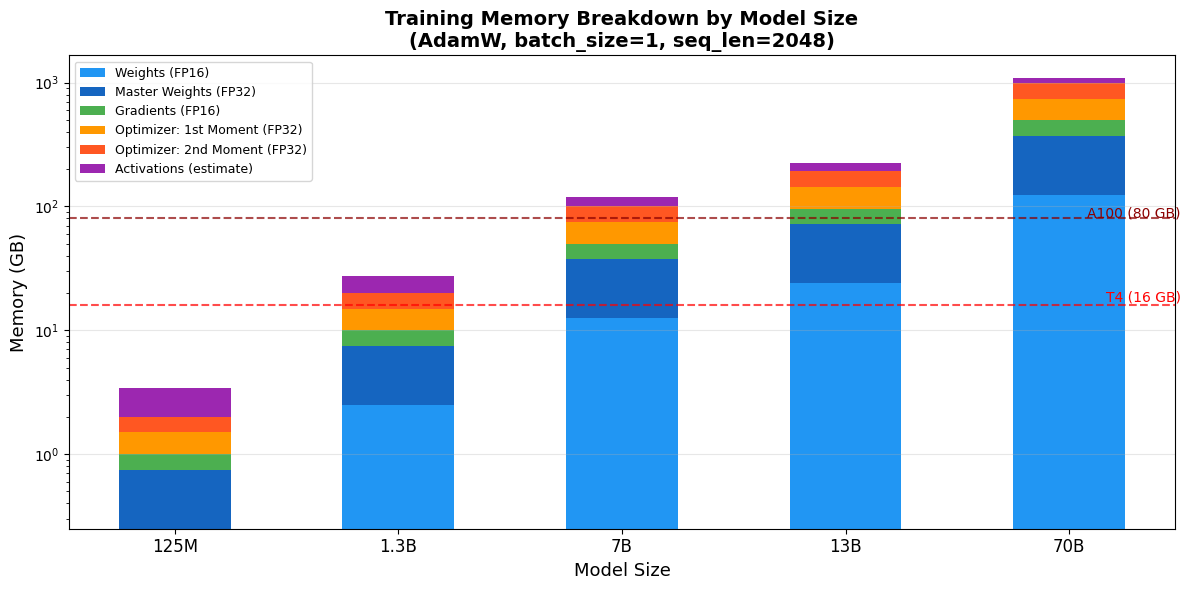

In [13]:
# Visualize memory breakdown for different model scales
model_configs = {
    '125M': (768, 12, 32000),
    '1.3B': (2048, 24, 32000),
    '7B':   (4096, 32, 32000),
    '13B':  (5120, 40, 32000),
    '70B':  (8192, 80, 128000),
}

categories = ['Weights (FP16)', 'Master Weights (FP32)', 'Gradients (FP16)',
              'Optimizer: 1st Moment (FP32)', 'Optimizer: 2nd Moment (FP32)', 'Activations (estimate)']
colors = ['#2196F3', '#1565C0', '#4CAF50', '#FF9800', '#FF5722', '#9C27B0']

fig, ax = plt.subplots(figsize=(12, 6))

model_names = list(model_configs.keys())
x = np.arange(len(model_names))
bar_width = 0.5

bottom = np.zeros(len(model_names))
for i, cat in enumerate(categories):
    values = []
    for name, (d, nl, vs) in model_configs.items():
        _, comps = analyze_training_memory.__wrapped__(d, nl, vs, 1, 2048) if hasattr(analyze_training_memory, '__wrapped__') else (None, None)
        # Recalculate inline
        d_ff = 4 * d
        params_per_layer = 4*d*d + 2*d*d_ff + 4*d
        tp = vs*d + nl*params_per_layer + d + vs*d
        mem_map = {
            'Weights (FP16)': tp * 2,
            'Master Weights (FP32)': tp * 4,
            'Gradients (FP16)': tp * 2,
            'Optimizer: 1st Moment (FP32)': tp * 4,
            'Optimizer: 2nd Moment (FP32)': tp * 4,
            'Activations (estimate)': nl * (1*2048*d*2*4 + 1*(d//64)*2048*2048*2 + 1*2048*d_ff*2),
        }
        values.append(mem_map[cat] / (1024**3))

    ax.bar(x, values, bar_width, bottom=bottom, label=cat, color=colors[i])
    bottom += np.array(values)

# Add GPU memory limit lines
ax.axhline(y=16, color='red', linestyle='--', alpha=0.7, linewidth=1.5)
ax.text(len(model_names)-0.5, 17, 'T4 (16 GB)', color='red', fontsize=10, ha='right')
ax.axhline(y=80, color='darkred', linestyle='--', alpha=0.7, linewidth=1.5)
ax.text(len(model_names)-0.5, 82, 'A100 (80 GB)', color='darkred', fontsize=10, ha='right')

ax.set_xlabel('Model Size', fontsize=13)
ax.set_ylabel('Memory (GB)', fontsize=13)
ax.set_title('Training Memory Breakdown by Model Size\n(AdamW, batch_size=1, seq_len=2048)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=12)
ax.legend(fontsize=9, loc='upper left')
ax.set_yscale('log')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


In [14]:
print("\nKey Insight: Even the 7B model exceeds a single A100's 80 GB memory.")
print("The optimizer states (1st + 2nd moment) alone take 56 GB for 7B params!")
print("This is why we NEED parallelism strategies to train large models.")


Key Insight: Even the 7B model exceeds a single A100's 80 GB memory.
The optimizer states (1st + 2nd moment) alone take 56 GB for 7B params!
This is why we NEED parallelism strategies to train large models.


## Part 5: Mixed Precision Training Preview

One way to reduce memory and increase speed is **mixed precision training** -- using FP16 for most computations while keeping FP32 for critical parts. Let's see the speedup.

In [15]:
# Compare FP32 vs mixed precision training step

model_fp32 = SimplifiedTransformer(d_model=512, n_heads=8, d_ff=2048, n_layers=6).to(device)
model_fp16 = SimplifiedTransformer(d_model=512, n_heads=8, d_ff=2048, n_layers=6).to(device)

optimizer_fp32 = torch.optim.AdamW(model_fp32.parameters(), lr=1e-4)
optimizer_fp16 = torch.optim.AdamW(model_fp16.parameters(), lr=1e-4)
scaler = torch.amp.GradScaler('cuda')

batch_size = 16
seq_len = 256
input_ids = torch.randint(0, 32000, (batch_size, seq_len), device=device)
targets = torch.randint(0, 32000, (batch_size, seq_len), device=device)
criterion = nn.CrossEntropyLoss()

# Warm up both
for m, opt in [(model_fp32, optimizer_fp32)]:
    logits = m(input_ids)
    loss = criterion(logits.view(-1, logits.size(-1)), targets.view(-1))
    loss.backward()
    opt.step()
    opt.zero_grad()

with torch.amp.autocast('cuda', dtype=torch.float16):
    logits = model_fp16(input_ids)
    loss = criterion(logits.view(-1, logits.size(-1)), targets.view(-1))
scaler.scale(loss).backward()
scaler.step(optimizer_fp16)
scaler.update()
optimizer_fp16.zero_grad()
torch.cuda.synchronize()

num_trials = 5

# FP32 timing
fp32_times = []
for _ in range(num_trials):
    optimizer_fp32.zero_grad()
    torch.cuda.synchronize()
    start = time.perf_counter()
    logits = model_fp32(input_ids)
    loss = criterion(logits.view(-1, logits.size(-1)), targets.view(-1))
    loss.backward()
    optimizer_fp32.step()
    torch.cuda.synchronize()
    fp32_times.append(time.perf_counter() - start)

# Mixed precision timing
fp16_times = []
for _ in range(num_trials):
    optimizer_fp16.zero_grad()
    torch.cuda.synchronize()
    start = time.perf_counter()
    with torch.amp.autocast('cuda', dtype=torch.float16):
        logits = model_fp16(input_ids)
        loss = criterion(logits.view(-1, logits.size(-1)), targets.view(-1))
    scaler.scale(loss).backward()
    scaler.step(optimizer_fp16)
    scaler.update()
    torch.cuda.synchronize()
    fp16_times.append(time.perf_counter() - start)

fp32_avg = np.median(fp32_times) * 1000
fp16_avg = np.median(fp16_times) * 1000


In [16]:
print(f"Training Step Timing:")
print(f"  FP32:           {fp32_avg:.2f} ms")
print(f"  Mixed Precision: {fp16_avg:.2f} ms")
print(f"  Speedup:        {fp32_avg/fp16_avg:.2f}x")

# Memory comparison
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()
logits = model_fp32(input_ids)
loss = criterion(logits.view(-1, logits.size(-1)), targets.view(-1))
loss.backward()
fp32_mem = torch.cuda.max_memory_allocated() / 1024**2

torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()
with torch.amp.autocast('cuda', dtype=torch.float16):
    logits = model_fp16(input_ids)
    loss = criterion(logits.view(-1, logits.size(-1)), targets.view(-1))
loss.backward()
fp16_mem = torch.cuda.max_memory_allocated() / 1024**2

print(f"\nPeak Memory Usage:")
print(f"  FP32:           {fp32_mem:.1f} MB")
print(f"  Mixed Precision: {fp16_mem:.1f} MB")
print(f"  Memory Savings: {(1 - fp16_mem/fp32_mem)*100:.1f}%")

Training Step Timing:
  FP32:           27.38 ms
  Mixed Precision: 23.09 ms
  Speedup:        1.19x

Peak Memory Usage:
  FP32:           5394.5 MB
  Mixed Precision: 4503.8 MB
  Memory Savings: 16.5%


## Exercises


### TODO Exercise 1: Scaling Laws -- How Training Time Grows with Model Size

Create models of increasing size (vary `d_model` from 128 to 1024 in steps) and measure how training step time scales. Plot:
1. Training step time vs. parameter count
2. GPU memory usage vs. parameter count

Does the relationship look linear, quadratic, or something else?

d_model= 128: params=   9.0M  step=  12.68ms  peak_mem=  3440.0MB
d_model= 256: params=  19.5M  step=  13.23ms  peak_mem=  3631.2MB
d_model= 384: params=  31.7M  step=  13.27ms  peak_mem=  3848.0MB
d_model= 512: params=  45.4M  step=  13.36ms  peak_mem=  4075.1MB
d_model= 640: params=  60.7M  step=  16.92ms  peak_mem=  4320.6MB
d_model= 768: params=  77.5M  step=  20.66ms  peak_mem=  4584.9MB
d_model= 896: params=  95.9M  step=  24.96ms  peak_mem=  4866.1MB
d_model=1024: params= 115.9M  step=  28.82ms  peak_mem=  5161.7MB


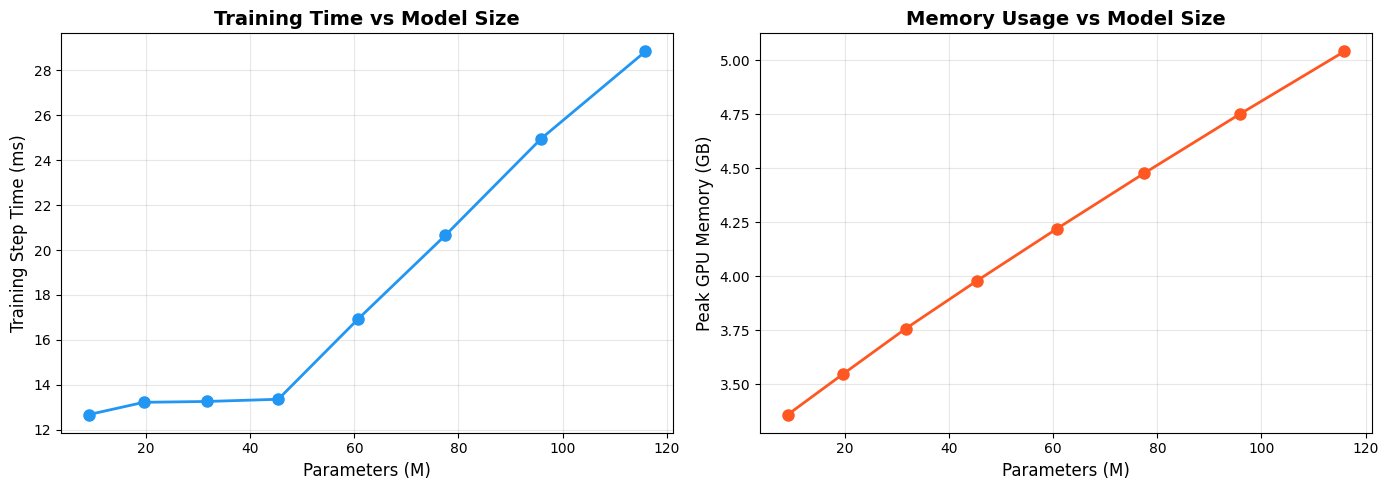


Both time and memory grow super-linearly with d_model.
This is because FLOPs scale as d_model² (matmul dimensions) and memory
includes activations that also scale with d_model.


In [17]:
# Exercise 1: Measure how training time and memory scale with model size

d_model_sizes = [128, 256, 384, 512, 640, 768, 896, 1024]
batch_size = 8
seq_len = 256

param_counts = []
step_times = []
peak_memories = []

criterion = nn.CrossEntropyLoss()

for d in d_model_sizes:
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    m = SimplifiedTransformer(d_model=d, n_heads=8, d_ff=4*d, n_layers=4).to(device)
    opt = torch.optim.AdamW(m.parameters(), lr=1e-4)

    num_params = sum(p.numel() for p in m.parameters())
    param_counts.append(num_params)

    input_ids = torch.randint(0, 32000, (batch_size, seq_len), device=device)
    targets = torch.randint(0, 32000, (batch_size, seq_len), device=device)

    # Warm up
    logits = m(input_ids)
    loss = criterion(logits.view(-1, logits.size(-1)), targets.view(-1))
    loss.backward()
    opt.step()
    opt.zero_grad()
    torch.cuda.synchronize()
    torch.cuda.reset_peak_memory_stats()

    # Measure time
    times = []
    for _ in range(5):
        opt.zero_grad()
        torch.cuda.synchronize()
        start = time.perf_counter()
        logits = m(input_ids)
        loss = criterion(logits.view(-1, logits.size(-1)), targets.view(-1))
        loss.backward()
        opt.step()
        torch.cuda.synchronize()
        times.append(time.perf_counter() - start)

    step_times.append(np.median(times) * 1000)
    peak_memories.append(torch.cuda.max_memory_allocated() / 1024**2)

    print(f"d_model={d:>4}: params={num_params/1e6:>6.1f}M  step={np.median(times)*1000:>7.2f}ms  peak_mem={peak_memories[-1]:>8.1f}MB")

    del m, opt, input_ids, targets
    torch.cuda.empty_cache()

# Plot results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot([p/1e6 for p in param_counts], step_times, 'o-', color='#2196F3', linewidth=2, markersize=8)
ax.set_xlabel('Parameters (M)', fontsize=12)
ax.set_ylabel('Training Step Time (ms)', fontsize=12)
ax.set_title('Training Time vs Model Size', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot([p/1e6 for p in param_counts], [m/1024 for m in peak_memories], 'o-', color='#FF5722', linewidth=2, markersize=8)
ax.set_xlabel('Parameters (M)', fontsize=12)
ax.set_ylabel('Peak GPU Memory (GB)', fontsize=12)
ax.set_title('Memory Usage vs Model Size', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nBoth time and memory grow super-linearly with d_model.")
print("This is because FLOPs scale as d_model² (matmul dimensions) and memory")
print("includes activations that also scale with d_model.")

### TODO Exercise 2: Find the Maximum Batch Size

For our SimplifiedTransformer model (d_model=512, n_layers=6), find the maximum batch size that fits in GPU memory.

Use binary search: start with a guess, if it works double it, if OOM halve it.

In [18]:
# Exercise 2: Find maximum batch size through binary search

def try_batch_size(model, batch_size, seq_len=256):
    """Try a training step with the given batch size. Returns True if successful."""
    try:
        torch.cuda.empty_cache()
        input_ids = torch.randint(0, 32000, (batch_size, seq_len), device=device)
        targets = torch.randint(0, 32000, (batch_size, seq_len), device=device)

        logits = model(input_ids)
        loss = nn.CrossEntropyLoss()(logits.view(-1, logits.size(-1)), targets.view(-1))
        loss.backward()

        del input_ids, targets, logits, loss
        torch.cuda.empty_cache()
        return True
    except RuntimeError as e:
        if 'out of memory' in str(e):
            torch.cuda.empty_cache()
            return False
        raise

# Create fresh model for this exercise
torch.cuda.empty_cache()
test_model = SimplifiedTransformer(d_model=512, n_heads=8, d_ff=2048, n_layers=6).to(device)
test_model.train()

# Binary search for max batch size
low, high = 1, 2048
print("Binary searching for maximum batch size (d_model=512, n_layers=6, seq_len=256)...")
print("-" * 60)

while low < high:
    mid = (low + high + 1) // 2
    test_model.zero_grad()
    success = try_batch_size(test_model, mid)
    status = "OK" if success else "OOM"
    print(f"  batch_size={mid:>5}: {status}")
    if success:
        low = mid
    else:
        high = mid - 1

max_batch = low
print(f"\nMax batch size: {max_batch}")

# Measure throughput at max batch size
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()
test_model.zero_grad()

input_ids = torch.randint(0, 32000, (max_batch, 256), device=device)
targets = torch.randint(0, 32000, (max_batch, 256), device=device)

# Warm up
logits = test_model(input_ids)
loss = nn.CrossEntropyLoss()(logits.view(-1, logits.size(-1)), targets.view(-1))
loss.backward()
test_model.zero_grad()
torch.cuda.synchronize()

# Time it
times = []
for _ in range(3):
    test_model.zero_grad()
    torch.cuda.synchronize()
    start = time.perf_counter()
    logits = test_model(input_ids)
    loss = nn.CrossEntropyLoss()(logits.view(-1, logits.size(-1)), targets.view(-1))
    loss.backward()
    torch.cuda.synchronize()
    times.append(time.perf_counter() - start)

step_time = np.median(times)
tokens_per_sec = max_batch * 256 / step_time
peak_mem = torch.cuda.max_memory_allocated() / 1024**3

print(f"At max batch size ({max_batch}):")
print(f"  Step time:       {step_time*1000:.1f} ms")
print(f"  Tokens/second:   {tokens_per_sec:,.0f}")
print(f"  Peak memory:     {peak_mem:.2f} GB")

del test_model, input_ids, targets
torch.cuda.empty_cache()

Binary searching for maximum batch size (d_model=512, n_layers=6, seq_len=256)...
------------------------------------------------------------
  batch_size= 1025: OOM
  batch_size=  513: OOM
  batch_size=  257: OK
  batch_size=  385: OOM
  batch_size=  321: OK
  batch_size=  353: OK
  batch_size=  369: OK
  batch_size=  377: OOM
  batch_size=  373: OOM
  batch_size=  371: OOM
  batch_size=  370: OK

Max batch size: 370
At max batch size (370):
  Step time:       532.5 ms
  Tokens/second:   177,876
  Peak memory:     76.29 GB


### TODO Exercise 3: Activation Checkpointing

Activation checkpointing (or gradient checkpointing) is a technique that trades compute for memory: instead of storing all intermediate activations, we recompute them during the backward pass.

Compare memory usage with and without `torch.utils.checkpoint.checkpoint` on our model.

In [19]:
# Exercise 3: Compare memory with and without activation checkpointing

from torch.utils.checkpoint import checkpoint

# Model WITHOUT checkpointing
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

model_no_ckpt = SimplifiedTransformer(d_model=512, n_heads=8, d_ff=2048, n_layers=6).to(device)
model_no_ckpt.train()

batch_size = 64
seq_len = 256
input_ids = torch.randint(0, 32000, (batch_size, seq_len), device=device)
targets = torch.randint(0, 32000, (batch_size, seq_len), device=device)

# Normal forward + backward
torch.cuda.reset_peak_memory_stats()
logits = model_no_ckpt(input_ids)
loss = nn.CrossEntropyLoss()(logits.view(-1, logits.size(-1)), targets.view(-1))
loss.backward()
torch.cuda.synchronize()
mem_no_ckpt = torch.cuda.max_memory_allocated() / 1024**2

# Time it
model_no_ckpt.zero_grad()
torch.cuda.synchronize()
times_no_ckpt = []
for _ in range(5):
    model_no_ckpt.zero_grad()
    torch.cuda.synchronize()
    start = time.perf_counter()
    logits = model_no_ckpt(input_ids)
    loss = nn.CrossEntropyLoss()(logits.view(-1, logits.size(-1)), targets.view(-1))
    loss.backward()
    torch.cuda.synchronize()
    times_no_ckpt.append(time.perf_counter() - start)

time_no_ckpt = np.median(times_no_ckpt) * 1000
del model_no_ckpt
torch.cuda.empty_cache()


# Model WITH checkpointing
class CheckpointedTransformer(nn.Module):
    """Transformer that uses activation checkpointing."""

    def __init__(self, d_model=512, n_heads=8, d_ff=2048, n_layers=6, vocab_size=32000):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, d_model)
        self.blocks = nn.ModuleList([
            SimplifiedTransformerBlock(d_model, n_heads, d_ff)
            for _ in range(n_layers)
        ])
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size, bias=False)

    def forward(self, x):
        x = self.embed(x)
        for block in self.blocks:
            x = checkpoint(block, x, use_reentrant=False)
        x = self.norm(x)
        return self.head(x)


torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

model_ckpt = CheckpointedTransformer(d_model=512, n_heads=8, d_ff=2048, n_layers=6).to(device)
model_ckpt.train()

# Checkpointed forward + backward
torch.cuda.reset_peak_memory_stats()
logits = model_ckpt(input_ids)
loss = nn.CrossEntropyLoss()(logits.view(-1, logits.size(-1)), targets.view(-1))
loss.backward()
torch.cuda.synchronize()
mem_ckpt = torch.cuda.max_memory_allocated() / 1024**2

# Time it
model_ckpt.zero_grad()
torch.cuda.synchronize()
times_ckpt = []
for _ in range(5):
    model_ckpt.zero_grad()
    torch.cuda.synchronize()
    start = time.perf_counter()
    logits = model_ckpt(input_ids)
    loss = nn.CrossEntropyLoss()(logits.view(-1, logits.size(-1)), targets.view(-1))
    loss.backward()
    torch.cuda.synchronize()
    times_ckpt.append(time.perf_counter() - start)

time_ckpt = np.median(times_ckpt) * 1000

# Results
print(f"Activation Checkpointing Comparison (batch={batch_size}, seq={seq_len}, 6 layers)")
print("=" * 60)
print(f"{'Metric':<25} {'Normal':>15} {'Checkpointed':>15}")
print("-" * 60)
print(f"{'Peak Memory (MB)':<25} {mem_no_ckpt:>15.1f} {mem_ckpt:>15.1f}")
print(f"{'Step Time (ms)':<25} {time_no_ckpt:>15.2f} {time_ckpt:>15.2f}")
print(f"{'Memory Savings':<25} {'—':>15} {(1 - mem_ckpt/mem_no_ckpt)*100:>14.1f}%")
print(f"{'Time Overhead':<25} {'—':>15} {(time_ckpt/time_no_ckpt - 1)*100:>14.1f}%")

print(f"\nCheckpointing saved {mem_no_ckpt - mem_ckpt:.0f} MB ({(1-mem_ckpt/mem_no_ckpt)*100:.1f}%) of memory")
print(f"at the cost of {(time_ckpt/time_no_ckpt - 1)*100:.1f}% more compute time.")
print("This tradeoff is worthwhile when you're near the GPU memory limit.")

del model_ckpt, input_ids, targets
torch.cuda.empty_cache()

Activation Checkpointing Comparison (batch=64, seq=256, 6 layers)
Metric                             Normal    Checkpointed
------------------------------------------------------------
Peak Memory (MB)                  21385.0         10571.6
Step Time (ms)                      95.71          115.22
Memory Savings                          —           50.6%
Time Overhead                           —           20.4%

Checkpointing saved 10813 MB (50.6%) of memory
at the cost of 20.4% more compute time.
This tradeoff is worthwhile when you're near the GPU memory limit.


In [20]:
print("\nActivation checkpointing reduces memory at the cost of ~33% more compute.")
print("This is essential for training models that are close to the GPU memory limit.")


Activation checkpointing reduces memory at the cost of ~33% more compute.
This is essential for training models that are close to the GPU memory limit.


## Summary

In this notebook, we have demonstrated:

1. **Neural networks are matrix multiplication machines** -- every linear layer is a matmul, and transformer layers are dominated by them

2. **A single transformer layer requires billions of FLOPs** -- for LLaMA-2 7B, one forward pass needs ~1.3 TFLOPs across 32 layers

3. **GPUs provide 50-500x speedup** for neural network operations compared to CPUs

4. **Training memory far exceeds model size** -- optimizer states alone can be 3x the weight memory, and activations grow with batch size

5. **Mixed precision training** can provide 1.3-2x speedup with 20-40% less memory

These findings explain why parallelism strategies (covered in Notebook 3 and the rest of this course) are not optional -- they are essential for training any modern LLM.

### Next Notebook

In Notebook 3, we will take a bird's-eye tour of the five parallelism strategies, with simple demos of how each one works.